# Aplicação de Multi-layer Perceptron à séries temporais variantes no tempo

Dataset
Qual o objetivo?
Quais são as técnicas para separação dos dados? (Validação cruzada)
Quais os possíveis problemas no treinamento;

Na arquitetura do Modelo, qual a técnica ultizada para a escolha dos hiperparâmetros.

Quais as métricas de validação usadas para avaliar o desempenho do modelo.

In [171]:
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from kfold import Kfold
from mlp_kfold import FFNeuralNetwork, Layer, Neuron

import requests
import pystac_client

def get_ts(sample):
    ts_ = json.loads(sample['time_series'])
    return pd.DataFrame(ts_)

def plot_ts(data_df, selected_line, step=5):

    ts = pd.DataFrame(json.loads(data_df['time_series'][selected_line]))

    fig = plt.figure(figsize=(10, 4))

    fig.suptitle(
        ("{cube} {label} [{lng:,.7f}, {lat:,.7f}] WGS 84 EPSG:4326 ").format(
            cube=data_df['cube'][selected_line],
            label=data_df['label'][selected_line],
            lng=data_df['longitude'][selected_line],
            lat=data_df['latitude'][selected_line]
        )
    )

    seaborn.set_theme(style="darkgrid")

    bands = [band for band in list(ts.keys()) if band != 'Index']

    for band in bands:
        seaborn.lineplot(
            data=ts,
            x="Index",
            y=band,
            label=band,
            markersize=8,
            marker='o',
            linestyle='-'
        )

    # intervalo dos xticks
    ax = plt.gca()

    xticks = range(0, len(ts["Index"]), step)

    ax.set_xticks(xticks)
    ax.set_xticklabels(
        ts["Index"].iloc[::step]
    )

    plt.xlabel(None)
    plt.ylabel(None)
    plt.legend()

    plt.tight_layout()
    plt.show()

# get bands description
service = pystac_client.Client.open("https://data.inpe.br/bdc/stac/v1/")
collection = service.get_collection('mod13q1-6.1').to_dict()
bands_description = collection['properties']['eo:bands']

# Recuperando a base de dados
samples = pd.read_csv('./samples/samples_mt_time_series.csv')

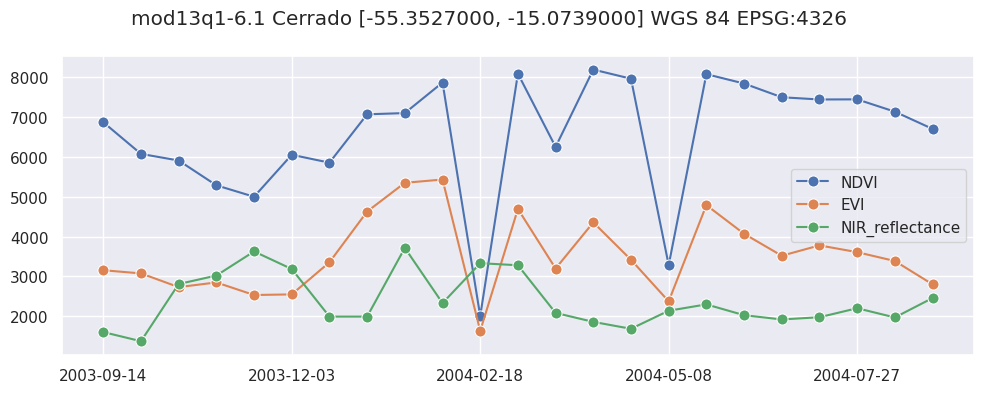

In [172]:
plot_ts(samples, random.randint(0, (len(samples) - 1)))

In [165]:
def get_band_description(band, bands_description):
    selected = {}
    for band_desc in bands_description:
        if band_desc['name'] == band:
            selected = band_desc
            break
    return selected
    
def normalize_ts(sample, line, bands_description):
    ts_ = pd.DataFrame(json.loads(sample['time_series'][line]))
    for column in ts_.columns:
        if column != "Index":
            band_desc = get_band_description(column, bands_description)
            scale = band_desc['scale']
            ts_[column] = ts_[column] * scale
    return ts_

def normalize_(samples, bands_description):
    samples_ = samples.copy()
    for row in range(0, len(samples_)):
        samples_.loc[row, 'time_series'] = json.dumps(normalize_ts(samples_, row, bands_description).to_dict(orient="list"))
    return samples_

samples_norm = normalize_(samples[:2], bands_description)
samples_norm

,longitude,latitude,label,start_date,end_date,cube,time_series
0,-55.9643,-10.0621,Pasture,2005-09-14,2006-08-29,mod13q1-6.1,"{""Index"": [""2005-09-14"", ""2005-09-30"", ""2005-1..."
1,-54.5540,-10.3749,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."


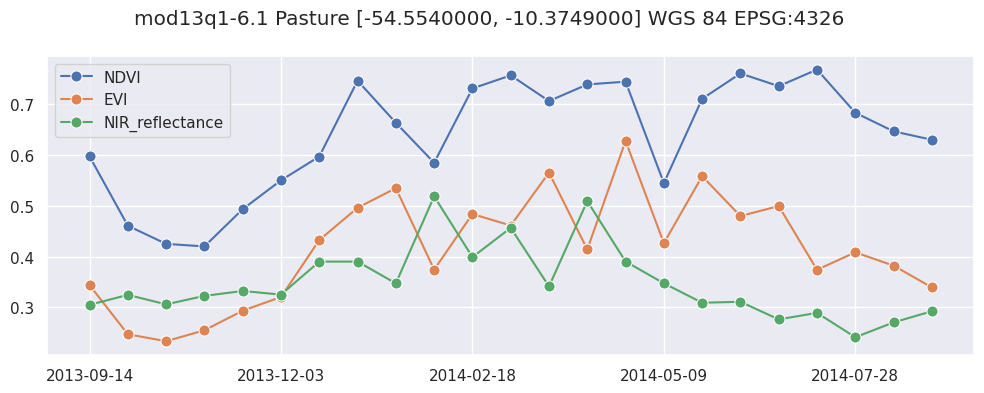

In [173]:
plot_ts(samples_norm, 1)